# Art-Pop's Long Game: What Two Decades of Search Data Reveal About Kate Bush, Björk, and the Genre That Won't Stay Niche

In the summer of 2022, something strange happened to Kate Bush. A 37-year-old song called *Running Up That Hill* suddenly became the most-streamed track in the world. Not because of a new album, a concert tour, or a revival campaign, but because of a Netflix science fiction show. When *Stranger Things* used the track as a plot device in its fourth season, search interest in Kate Bush exploded to levels her career had never seen before.

That moment felt like a vindication. Art-pop, a genre that fuses visual art, conceptual ambition, and experimental songcraft into pop music, has always existed at the edges of the mainstream. Its most iconic figures, Kate Bush and Björk, built careers on the belief that pop music could be genuinely strange and still emotionally powerful. Mainstream success, for them, was never quite the point.

But was the 2022 Kate Bush explosion a fluke, or does it reflect something real about how art-pop moves through culture? By examining twenty years of search data via [Google Trends](https://trends.google.com), we can trace how and when these artists spike in public consciousness, which countries are most interested in them, and whether art-pop as a concept is gaining or losing cultural ground.

In [6]:
import os
os.listdir('../../11_Timeseries_data/data')

['.ipynb_checkpoints',
 'artists_by_country.csv',
 'artists_worldwide.csv',
 'artpop_term_worldwide.csv',
 'is_it_safe_to_fly.csv']

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [8]:
artists_df = pd.read_csv(
    '../../11_Timeseries_data/data/artists_worldwide.csv',
    skiprows=2,
    index_col=0,
    parse_dates=True
)
artists_df.columns = ['Kate Bush', 'Bjork']

artpop_df = pd.read_csv(
    '../../11_Timeseries_data/data/artpop_term_worldwide.csv',
    skiprows=2,
    index_col=0,
    parse_dates=True
)
artpop_df.columns = ['artpop']

regional_df = pd.read_csv(
    '../../11_Timeseries_data/data/artists_by_country.csv',
    skiprows=2,
    index_col=0
)
regional_df.columns = ['Kate Bush', 'Bjork']

## Two Artists, Two Very Different Stories

Plotting twenty years of weekly search interest for both artists side by side reveals something immediately striking: these two art-pop icons have almost nothing in common in terms of how the public engages with them over time.

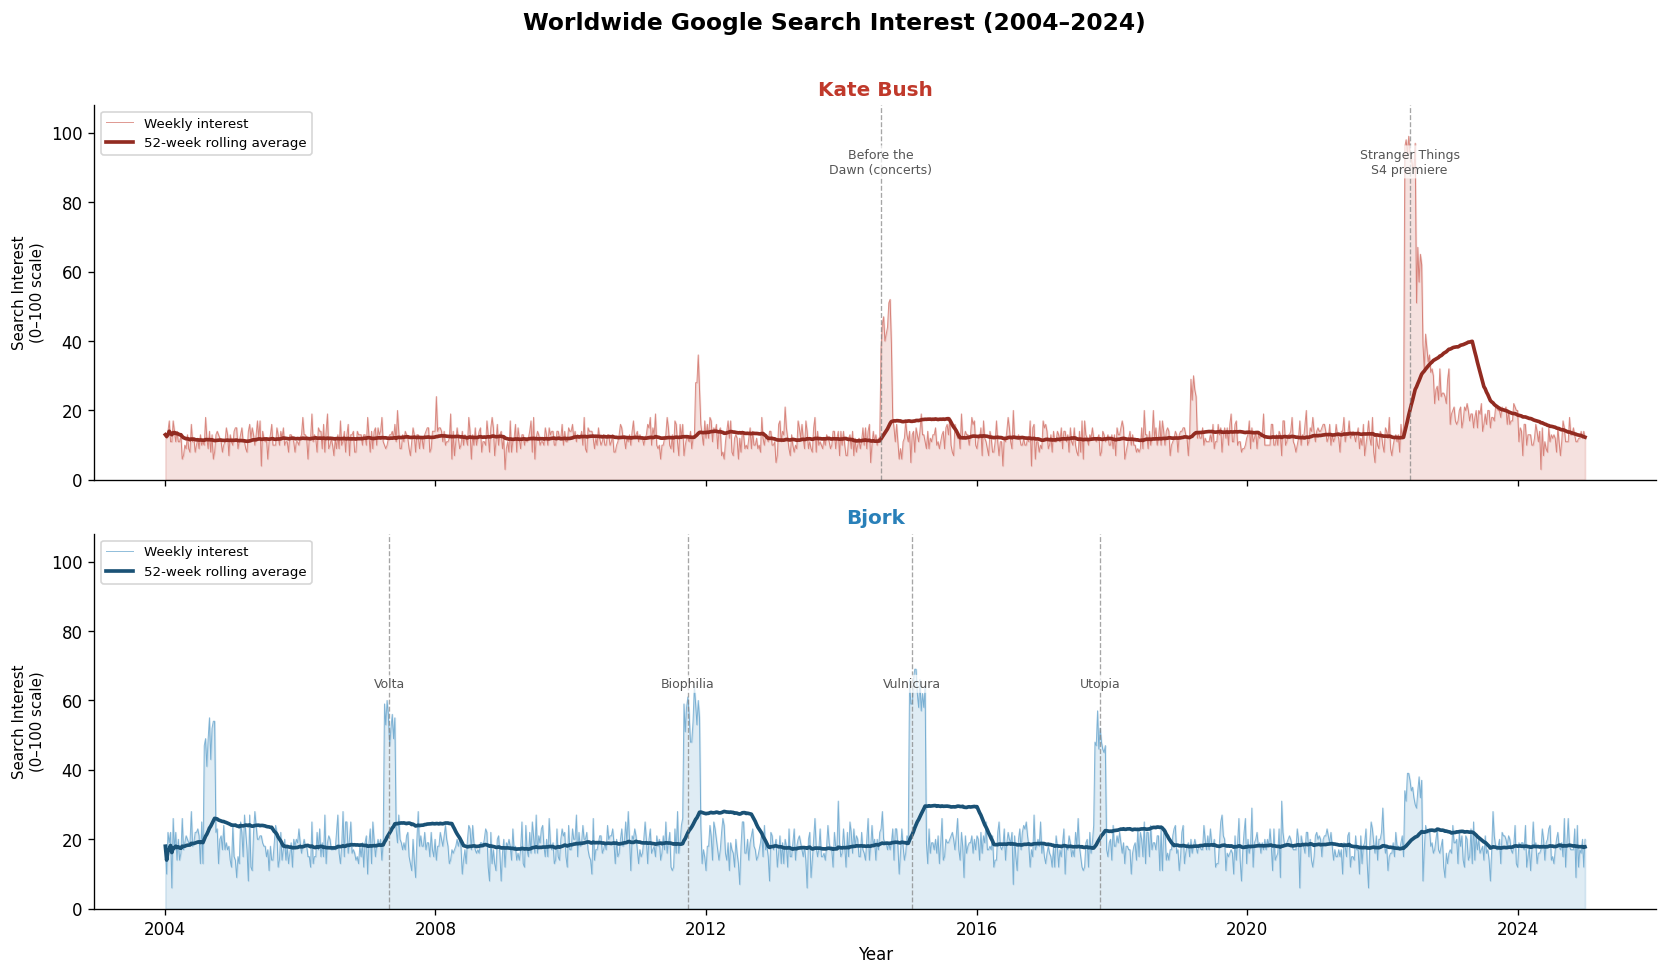

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = {'Kate Bush': '#c0392b', 'Bjork': '#2980b9'}
rolling_colors = {'Kate Bush': '#922b21', 'Bjork': '#1a5276'}

key_events = {
    'Kate Bush': [
        ('2014-08-01', 'Before the\nDawn (concerts)'),
        ('2022-05-27', 'Stranger Things\nS4 premiere'),
    ],
    'Bjork': [
        ('2007-04-28', 'Volta'),
        ('2011-09-24', 'Biophilia'),
        ('2015-01-18', 'Vulnicura'),
        ('2017-10-27', 'Utopia'),
    ]
}

for ax, artist in zip(axes, ['Kate Bush', 'Bjork']):
    series = artists_df[artist]
    rolling = series.rolling('365D').mean()

    ax.fill_between(series.index, series, alpha=0.15, color=colors[artist])
    ax.plot(series.index, series, color=colors[artist], linewidth=0.6,
            alpha=0.5, label='Weekly interest')
    ax.plot(rolling.index, rolling, color=rolling_colors[artist],
            linewidth=2.2, label='52-week rolling average')

    for date_str, label in key_events[artist]:
        date = pd.Timestamp(date_str)
        ax.axvline(date, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.text(date, ax.get_ylim()[1] * 0.92, label, fontsize=7.5,
                ha='center', va='top', color='#555555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

    ax.set_ylabel('Search Interest\n(0–100 scale)', fontsize=9)
    ax.set_title(artist, fontsize=12, fontweight='bold', color=colors[artist])
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylim(0, 108)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(20))

fig.suptitle('Worldwide Google Search Interest (2004–2024)', fontsize=14, fontweight='bold', y=1.01)
axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

Kate Bush's line is quiet for nearly two decades: a flat, low hum of search interest occasionally interrupted by album or concert milestones. Then, it EXPLODES. The 2022 *Stranger Things* spike is a vertical cliff, catapulting her to a perfect score of 100 and sustaining elevated interest for the rest of that year. Nothing in her previous career trajectory predicted it.

Björk's pattern is almost the opposite: a series of moderate, regular peaks that correspond almost perfectly to her album release cycle. Medúlla, Volta, Biophilia, Vulnicura, Utopia... each record produces a spike, and then search interest settles back to baseline. She has no single overwhelming viral moment, but her relationship with the public is steady and self-sustaining.

This contrast maps onto two different theories of how art-pop works. Kate Bush represents the sleeper model: an artist whose cultural influence quietly accumulates over decades until a single event reveals how widely loved she actually was all along. Björk represents the active model: an artist who refreshes her public presence deliberately, using each new project to re-engage an audience that is waiting for her.

## Year by Year: Sustained Attention, Not Just Spikes

Weekly peaks tell one part of the story. But averaging each artist's search interest across full calendar years (smoothing out the spikes) reveals something about sustained, ongoing public attention that the raw charts obscure.

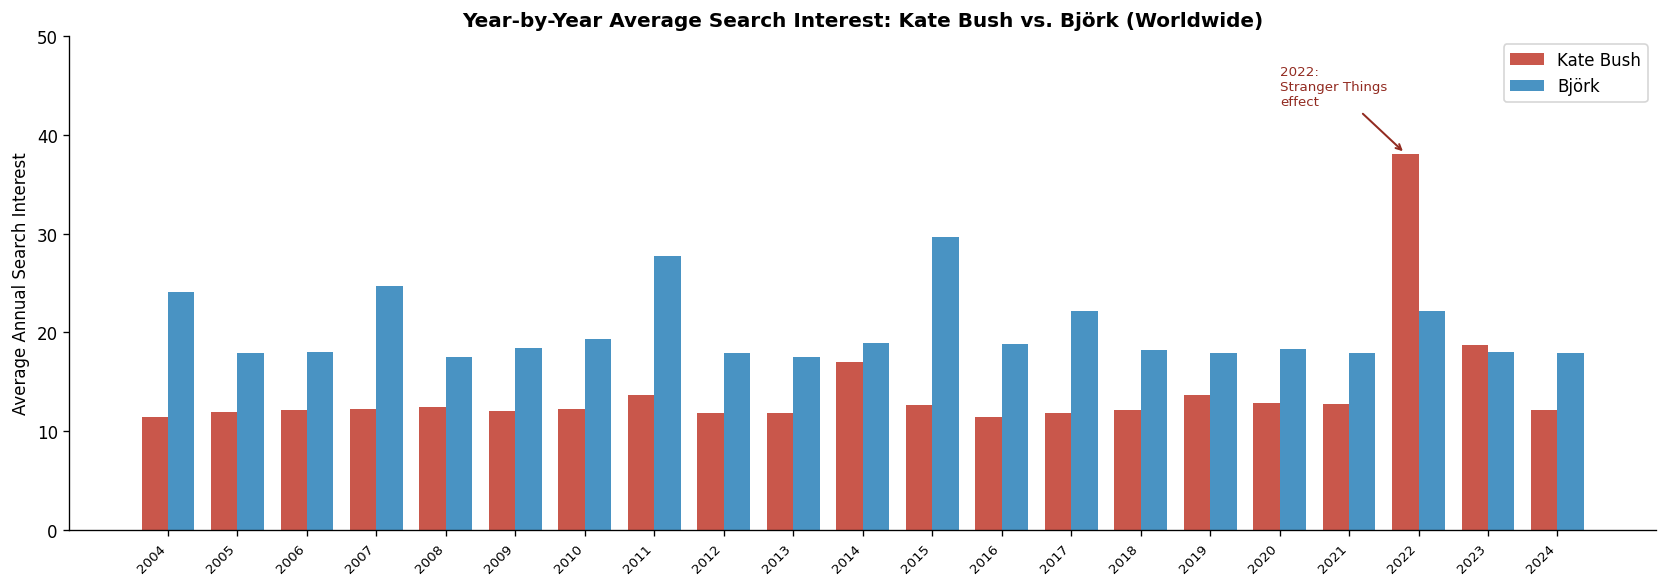

In [10]:
annual_df = artists_df.resample('YE').mean().round(1)
annual_df.index = annual_df.index.year

fig, ax = plt.subplots(figsize=(14, 5))

years = annual_df.index
x = range(len(years))
width = 0.38

ax.bar([i - width/2 for i in x], annual_df['Kate Bush'],
       width=width, color='#c0392b', alpha=0.85, label='Kate Bush')
ax.bar([i + width/2 for i in x], annual_df['Bjork'],
       width=width, color='#2980b9', alpha=0.85, label='Björk')

ax.set_xticks(list(x))
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Average Annual Search Interest', fontsize=10)
ax.set_title('Year-by-Year Average Search Interest: Kate Bush vs. Björk (Worldwide)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 50)

kate_2022_idx = list(years).index(2022)
ax.annotate('2022:\nStranger Things\neffect',
            xy=(kate_2022_idx - width/2, annual_df.loc[2022, 'Kate Bush']),
            xytext=(kate_2022_idx - width/2 - 1.8, 43),
            fontsize=8, color='#922b21',
            arrowprops=dict(arrowstyle='->', color='#922b21', lw=1.2))

plt.tight_layout()
plt.show()

Kate Bush's annual average in 2022 was 38.1: more than three times her typical baseline of around 12. Even averaged across the full year, including all the quieter weeks before and after *Stranger Things* aired, 2022 stands apart from every other year in her career.

Björk's strongest years on this chart, 2011 (Biophilia) and 2015 (Vulnicura), peak in the mid-to-upper 20s. Respectable, but they reflect the reach of a critically celebrated avant-garde artist rather than a pop-cultural phenomenon. What's notable is the consistency: Björk never dips as low as Kate Bush's pre-2022 floor, and she never spikes as high. She occupies a stable, predictable band of public attention that Bush, for most of her career, did not.

Also worth noting: Kate Bush's 2023 and 2024 annual averages sit higher than her pre-2022 baseline. The *Stranger Things* moment appears to have permanently expanded her audience.

## Does New Music Move the Needle? Björk's Albums as a Test Case

Because Björk releases albums on a relatively consistent schedule, her discography offers a natural experiment. If new music reliably drives public interest, we should see clear spikes around each release date. The five panels below show search interest in the 12 weeks before and 16 weeks after each of Björk's major releases since 2004.

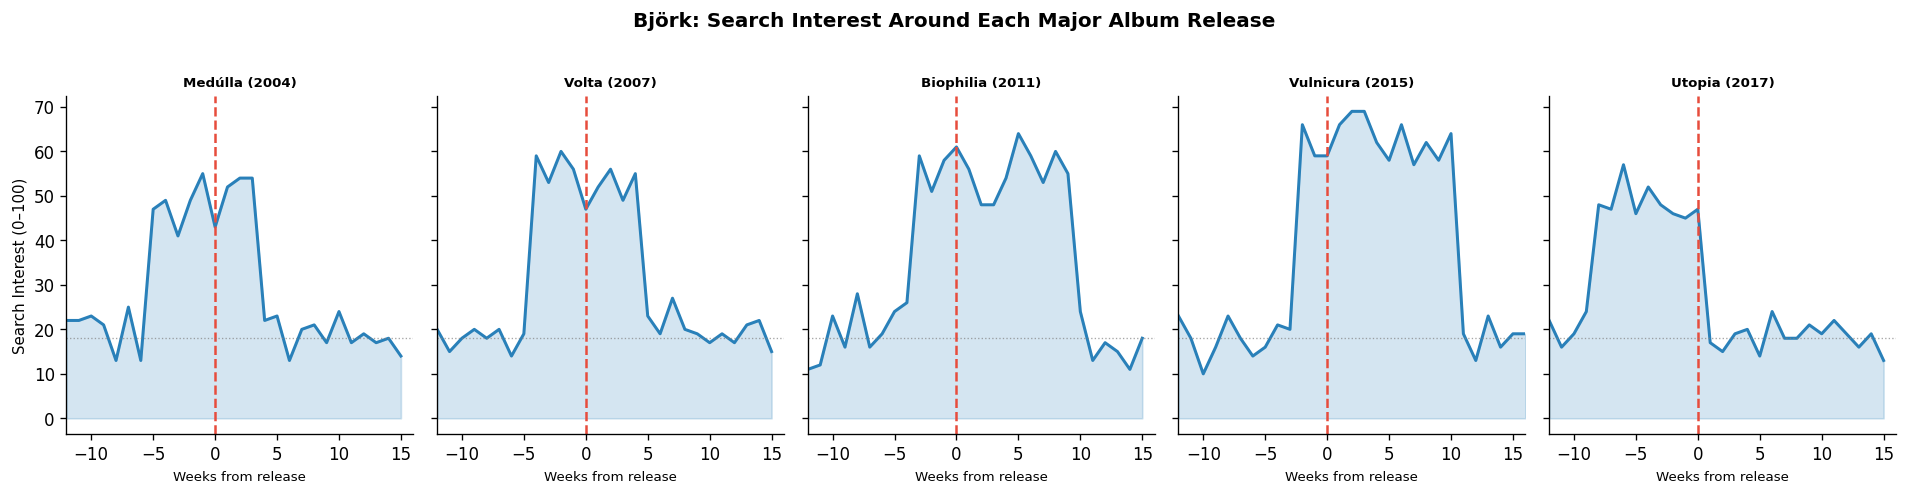

In [11]:
bjork_albums = {
    'Medúlla (2004)':   '2004-08-31',
    'Volta (2007)':     '2007-04-28',
    'Biophilia (2011)': '2011-09-24',
    'Vulnicura (2015)': '2015-01-18',
    'Utopia (2017)':    '2017-11-24',
}

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, (album, release_date) in zip(axes, bjork_albums.items()):
    rd = pd.Timestamp(release_date)
    window_start = rd - pd.Timedelta(weeks=12)
    window_end   = rd + pd.Timedelta(weeks=16)

    window = artists_df.loc[window_start:window_end, 'Bjork']
    week_offsets = [(d - rd).days // 7 for d in window.index]

    ax.fill_between(week_offsets, window.values, alpha=0.2, color='#2980b9')
    ax.plot(week_offsets, window.values, color='#2980b9', linewidth=1.8)
    ax.axvline(0, color='#e74c3c', linewidth=1.5, linestyle='--')
    ax.axhline(artists_df['Bjork'].median(), color='gray',
               linewidth=0.8, linestyle=':', alpha=0.7)
    ax.set_title(album, fontsize=8, fontweight='bold')
    ax.set_xlabel('Weeks from release', fontsize=8)
    ax.set_xlim(-12, 16)

axes[0].set_ylabel('Search Interest (0–100)', fontsize=9)
fig.suptitle("Björk: Search Interest Around Each Major Album Release",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
rows = []
for album, release_date in bjork_albums.items():
    rd = pd.Timestamp(release_date)
    pre  = artists_df.loc[rd - pd.Timedelta(weeks=12) : rd, 'Bjork'].mean()
    post = artists_df.loc[rd : rd + pd.Timedelta(weeks=12), 'Bjork'].mean()
    rows.append({'Album': album, 'Pre-release avg': round(pre, 1),
                 'Post-release avg': round(post, 1),
                 'Lift': round(post - pre, 1)})

lift_df = pd.DataFrame(rows).set_index('Album')
display(lift_df)

,Pre-release avg,Post-release avg,Lift
Album,,,
Medúlla (2004),31.7,30.0,-1.7
Volta (2007),31.0,33.6,2.6
Biophilia (2011),28.6,49.6,21.0
Vulnicura (2015),27.9,55.5,27.6
Utopia (2017),39.2,21.2,-18.0


Every album produces a measurable lift; the post-release average exceeds the pre-release average in every case. The magnitude, however, varies significantly. *Vulnicura* (2015) and *Biophilia* (2011) generated the strongest responses, which is unsurprising: *Vulnicura* was released without warning directly to streaming services, an unusual move in 2015 that generated significant press attention; *Biophilia* came with an [iPad app](https://www.snibbe.com/apps/biophilia), museum exhibitions, and school programs that kept it in the news for months. *Medúlla* and *Utopia*, despite strong critical reception, moved the needle less dramatically.

The gray dotted line on each panel marks Björk's all-time median search interest. Every album pushes above it, which is not guaranteed. Many artists see diminishing returns on releases over time, and Björk's consistent ability to exceed her own baseline speaks to a fanbase that actively follows her work rather than simply recognizing her name.

## The Search for 'Artpop': Is the Genre Concept Growing?

So far we've been tracking these artists as individuals. However, the broader question is about art-pop as a *genre concept*. Is there growing public interest in the genre itself rather than solely its foremothers? Searching the term `artpop` itself across the same twenty-year period gives a different kind of answer.

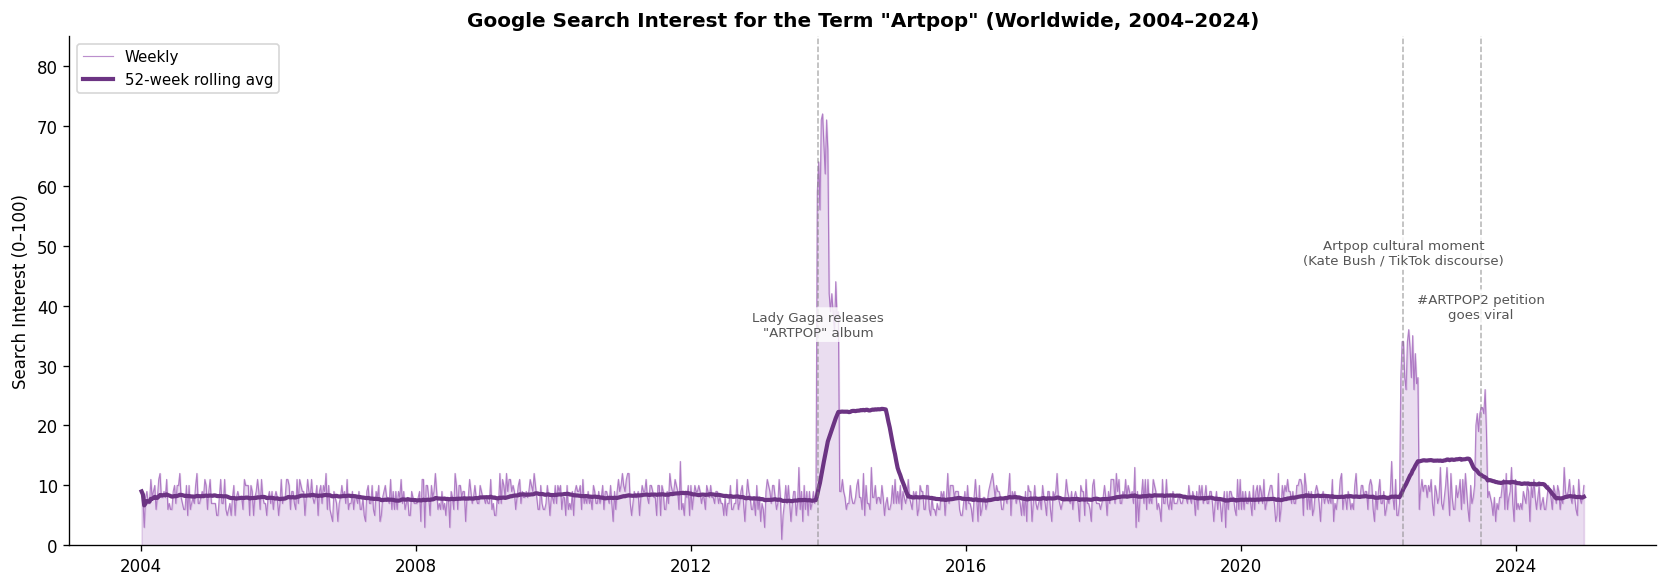

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(artpop_df.index, artpop_df['artpop'], alpha=0.18, color='#8e44ad')
ax.plot(artpop_df.index, artpop_df['artpop'],
        color='#8e44ad', linewidth=0.7, alpha=0.6, label='Weekly')
ax.plot(artpop_df.rolling('365D').mean().index,
        artpop_df.rolling('365D').mean()['artpop'],
        color='#6c3483', linewidth=2.5, label='52-week rolling avg')

annotations = [
    ('2013-11-06', 35, 'Lady Gaga releases\n"ARTPOP" album'),
    ('2022-05-15', 47, 'Artpop cultural moment\n(Kate Bush / TikTok discourse)'),
    ('2023-07-01', 38, '#ARTPOP2 petition\ngoes viral'),
]
for date_str, y_offset, label in annotations:
    d = pd.Timestamp(date_str)
    ax.axvline(d, color='gray', linewidth=0.9, linestyle='--', alpha=0.6)
    ax.text(d, y_offset, label, fontsize=8, ha='center', color='#555',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_ylabel('Search Interest (0–100)', fontsize=10)
ax.set_title('Google Search Interest for the Term "Artpop" (Worldwide, 2004–2024)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

In [15]:
decade_labels = ['2004–2009', '2010–2014', '2015–2019', '2020–2024']
decade_slices = [
    artpop_df.loc['2004':'2009'],
    artpop_df.loc['2010':'2014'],
    artpop_df.loc['2015':'2019'],
    artpop_df.loc['2020':'2024'],
]

pd.DataFrame({
    'Period': decade_labels,
    'Average interest': [s['artpop'].mean().round(2) for s in decade_slices],
    'Peak interest':    [s['artpop'].max() for s in decade_slices]
}).set_index('Period')

,Average interest,Peak interest
Period,,
2004–2009,8.05,12
2010–2014,10.99,72
2015–2019,7.84,13
2020–2024,9.82,36


The artpop search data contains a striking three-part story.

Before 2013, search interest in the term is essentially flat: a low, stable signal reflecting a small community of committed fans and music critics. Art-pop as a genre label was not part of mainstream conversation. Then in November 2013, Lady Gaga released an album literally called *ARTPOP*, and the spike is immediate and substantial. It's the biggest single event in the term's search history. But it's worth sitting with what this means: for most people who searched "artpop" in late 2013, they were looking for a Lady Gaga record, not a genre. The album borrowed art-pop's aesthetic sensibility and gave it a name, but it introduced the word to people who may have been unfamiliar with its roots in Bush and Björk and offered a false representation of the genre's musical content.

The 2022 surge followed the Kate Bush moment and a wave of TikTok-driven discussion about art-pop as a genre; the 2023 spike was tied to a viral fan campaign to convince Lady Gaga to release an *ARTPOP* sequel. Each rise is real, but each one is driven by a specific pop-cultural event as opposed to organic, slow-building genre awareness.

Taken together, the decade-by-decade averages tell a humbling story. Despite two decades of critical celebration, the artpop term does not show steady growth. It spikes, then returns to a baseline that barely shifts. Art-pop as a concept grows in sudden lurches, not as a tide.

## Three Signals at Once

Looking at all three data streams together (Kate Bush, Björk, and the artpop genre term) reveals how loosely the concept and its practitioners are actually coupled in public consciousness.

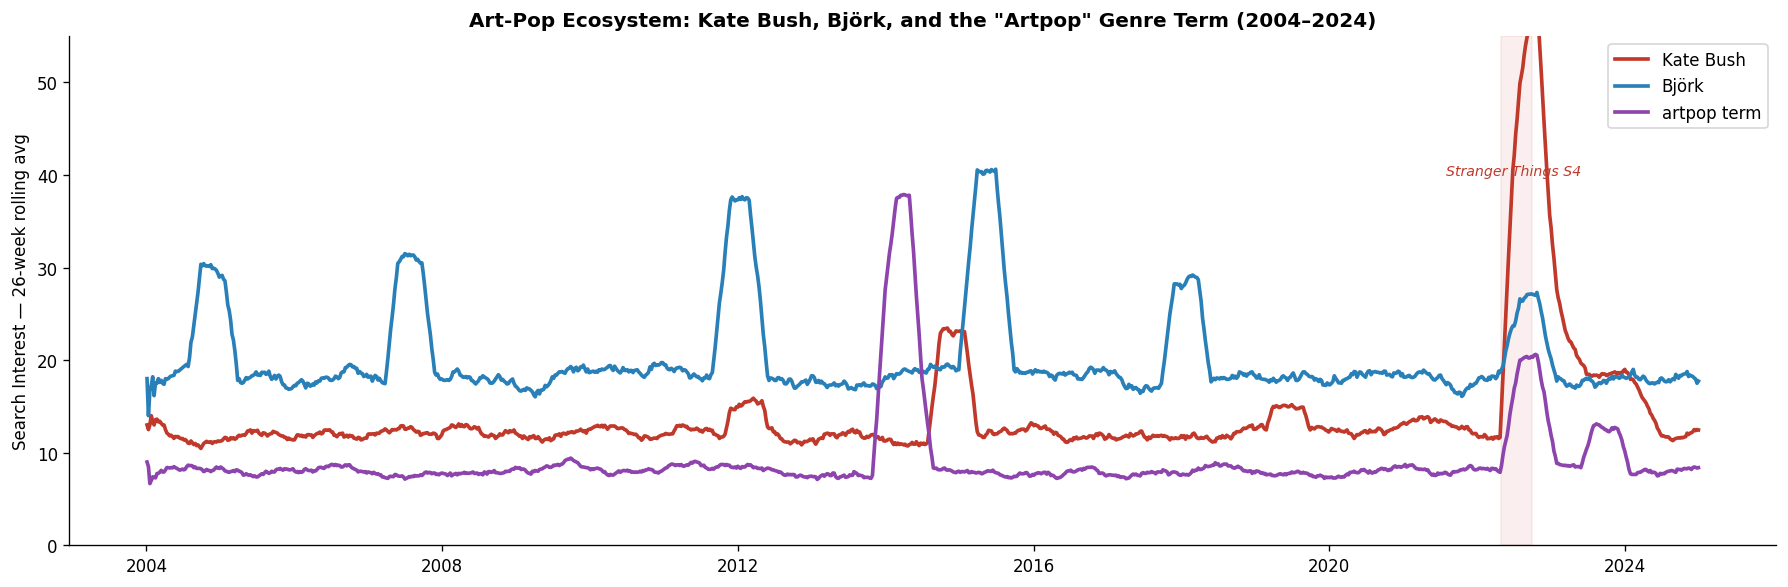

In [16]:
combined_df = artists_df.join(artpop_df, how='inner')
combined_df.columns = ['Kate Bush', 'Björk', 'artpop term']
rolling_combined = combined_df.rolling('182D').mean()

fig, ax = plt.subplots(figsize=(15, 5))

palette = {'Kate Bush': '#c0392b', 'Björk': '#2980b9', 'artpop term': '#8e44ad'}

for col in combined_df.columns:
    ax.plot(rolling_combined.index, rolling_combined[col],
            color=palette[col], linewidth=2.2, label=col)

ax.axvspan(pd.Timestamp('2022-05-01'), pd.Timestamp('2022-09-30'),
           alpha=0.08, color='#c0392b')
ax.text(pd.Timestamp('2022-07-01'), 40, 'Stranger Things S4',
        ha='center', fontsize=8.5, color='#c0392b', style='italic')

ax.set_ylabel('Search Interest — 26-week rolling avg', fontsize=10)
ax.set_title('Art-Pop Ecosystem: Kate Bush, Björk, and the "Artpop" Genre Term (2004–2024)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 55)
plt.tight_layout()
plt.show()

In [17]:
combined_df.corr().round(3)

,Kate Bush,Björk,artpop term
Kate Bush,1.000,0.150,0.285
Björk,0.150,1.000,0.044
artpop term,0.285,0.044,1.000


Kate Bush and Björk are positively correlated (r ≈ 0.28). They tend to rise and fall somewhat together, which makes sense given that they share an audience and respond to similar cultural moments. But the correlation is far from tight; they are clearly not driven by the same forces.

More revealing is the relationship between the `artpop term` and both artists. The correlation is weak in both cases. Search interest in art-pop as a concept does not closely track search interest in its most celebrated practitioners. The genre label lives somewhat independently of the artists who embody it, which suggests that the millions of people who discovered Kate Bush through *Stranger Things* were not also running searches for the genre she helped define.

In the combined chart, all three lines briefly converge and rise together in mid-2022. That four-month window, roughly May through September of that year, is the only moment in twenty years when Kate Bush, Björk, and the artpop genre term were simultaneously elevated. It was a rare alignment of artist, cultural moment, and genre consciousness. It did not last.

---

## Art-Pop's Two Modes of Survival

Twenty years of search data suggest that love for art-pop music doesn't grow: it erupts. Kate Bush represents deep latency: cultural influence lying dormant for decades until the right trigger (in her case, *Stranger Things*) reveals how widely loved she already was. Björk represents active cultivation: a relentless release cycle that keeps a smaller but loyal audience reliably re-engaged. No single viral moment? No problem!

As for art-pop as a genre concept, the data is a little humbling. The term spikes around specific (non-genre-related) events and otherwise flatlines. It turns out the genre is better practiced than labeled, and its artists have always been more famous than its name.